# Session 7 — calculus: how models learn

Data Science & AI. Module 1 Part 2.

Calculus is **the mathematics of change** *(slide 28)* — and the reason it
is on a data science course is one sentence: *training a model means
adjusting its numbers to make the error smaller, and calculus is how you
know which way "smaller" is.* Every model in Modules 4 to 8, up to and
including ChatGPT's ancestors, learns by the method you will build from
scratch tonight: **gradient descent**.

The deck's promise holds here too: differentiation is *the slope of a
curve*, integration is *the area under it*. If you can read a hillside,
you can do tonight.

No algebra gymnastics. We will let the computer take every derivative
numerically, and keep our heads free for what a derivative *is*.

## Before you type anything

**Work on your own copy, not on this file**, then **Restart & Run All**.

Pen again tonight: when we get to gradient descent, sketching the path
down the curve on paper — the deck's own advice for this session — beats
staring at the numbers.

In [1]:
# ==========================================================
# Setup. Run this once, then carry on.
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)
print("NumPy:", np.__version__)

NumPy: 2.4.6


## 1. Limits: sneaking up on a value  *(slides 29, 30)*

A **limit** asks: as x creeps toward some point p, what value does f(x)
creep toward? Written lim f(x) = L. It matters because the derivative — in
two sections' time — is *defined* as a limit, so we warm up on the idea
itself.

Take f(x) = $\dfrac{(x² − 1)}{(x − 1)}$. At x = 1 exactly, this is 0/0 — undefined.
But watch what happens as we *approach* 1:

In [2]:
def f(x):
    return (x**2 - 1) / (x - 1)

for x in [0.9, 0.99, 0.999, 1.001, 1.01, 1.1]:
    print("x = {:<6}  f(x) = {:.4f}".format(x, f(x)))

x = 0.9     f(x) = 1.9000
x = 0.99    f(x) = 1.9900
x = 0.999   f(x) = 1.9990
x = 1.001   f(x) = 2.0010
x = 1.01    f(x) = 2.0100
x = 1.1     f(x) = 2.1000


From both sides, f(x) closes in on **2**. The function has a hole at
x = 1, but the limit exists and equals 2 — the value the function is
*pointing at* even where it cannot speak.

Two footnotes from the deck and no more: approaching from the left and
the right can disagree, in which case the limit at that point does not
exist.

## 2. The derivative: slope, measured honestly  *(slide 31)*

Physical version first, because you already own this concept: **a
speedometer takes a derivative.** Your position along the road is a
curve through time; your *speed* is how steeply that curve climbs right
now. An odometer 100 km apart at 9:00 and 10:00 gives *average* speed —
distance over time, a **secant** through two points. The speedometer
needle shows the *instantaneous* speed — the slope at one moment, the
**tangent**. The whole definition of the derivative is just: average
speed over a shorter and shorter interval.

So take a drag car whose position is s(t) = t² metres after t seconds —
our f(x) = x², wearing physics. How fast at t = 3? Measure the average
speed over a step h and shrink it:

slope ≈ ( f(x + h) − f(x) ) / h

In [ ]:
def g(x):
    return x**2

x0 = 3.0
for h in [1, 0.1, 0.01, 0.001, 0.0001]:
    slope = (g(x0 + h) - g(x0)) / h
    print("h = {:<8}  slope = {:.4f}".format(h, slope))

> **Predict first.** The slopes are marching toward a whole number. Which one — and if you know the classroom rule for the derivative of x², say where the 6 comes from.
>
> Put your answer in the chat before we run it.

**6.** The car is doing 6 m/s at t = 3, and the textbook rule agrees:
the derivative of x² is 2x, and 2 × 3 = 6 — our shrinking-h experiment
recovers it without any algebra. This numeric recipe is called a
**finite difference**, and it is how you will sanity-check any
derivative for the rest of the course.

Watch the shrinking happen as a picture — each secant uses a smaller h,
and they tilt into the tangent:

In [ ]:
xs = np.linspace(0, 6, 100)
plt.figure(figsize=(8, 4.5))
plt.plot(xs, g(xs), lw=2.5, label="position s(t) = t$^2$")

for h in [2, 1, 0.5]:
    slope = (g(3 + h) - g(3)) / h
    plt.plot(xs, 9 + slope * (xs - 3), "--",     # a line through (3, 9)
             label="secant, h = {} (slope {:.1f})".format(h, slope))

plt.scatter([3], [9], color="tab:red", zorder=5)
plt.ylim(-5, 40)
plt.legend(); plt.grid(alpha=0.3)
plt.title("Secants tilting into the tangent as h shrinks")
plt.show()

The limiting line is the **tangent** — the straight line that kisses the
curve at x = 3 with slope exactly 6, the speedometer's number:

In [ ]:
xs = np.linspace(0, 6, 100)
plt.figure(figsize=(8, 4))
plt.plot(xs, g(xs), lw=2, label="f(x) = x$^2$")
plt.plot(xs, 6 * (xs - 3) + 9, "--", color="tab:red",
         label="tangent at x=3, slope 6")
plt.scatter([3], [9], zorder=5, color="tab:red")
plt.legend(); plt.grid(alpha=0.3)
plt.title("The derivative is the slope of the tangent")
plt.show()

Wrap the recipe in a function once, and we own a derivative machine for
the whole evening:

In [ ]:
def derivative(f, x, h=1e-6):
    """Slope of f at x, by finite difference."""
    return (f(x + h) - f(x)) / h

print("d/dx x^2   at 3:", derivative(g, 3))
print("d/dx sin(x) at 0:", derivative(np.sin, 0))   # textbook: cos(0) = 1

### Deliberate error

If a small h is good, surely h = 0.0000000000000001 is better?

In [ ]:
h = 1e-16
slope = (g(3 + h) - g(3)) / h
assert slope > 5, "slope came out as {} - it should be near 6!".format(slope)

The slope comes out **0.0** — completely wrong, and no error message
would have told you. In floating point, `3 + 1e-16` *is* 3 (recall the
float-precision surprises from the NumPy session), so the difference on
top is exactly zero. Numerical maths lives between two cliffs: h too big
measures a secant, h too small drowns in rounding. Around 1e-6 is the
sweet spot for float64 — which is why `derivative` defaults to it.

## 3. The rules, in one cell each  *(slide 32)*

You never need to hand-derive on this course, but three rules from the
deck are worth *recognising*, because papers and error messages assume
them. We state each and let the machine confirm it at a random point.

**Linearity**: the derivative of a·f + b·g is a·f′ + b·g′ — derivatives
pass through sums and constant multiples.

In [ ]:
x0 = 1.7
lhs = derivative(lambda x: 3 * g(x) + 2 * np.sin(x), x0)
rhs = 3 * derivative(g, x0) + 2 * derivative(np.sin, x0)
print(lhs, "=", rhs)

**Product rule**: (f·g)′ = f′·g + f·g′ — *not* f′·g′.

In [ ]:
lhs = derivative(lambda x: g(x) * np.sin(x), x0)
rhs = derivative(g, x0) * np.sin(x0) + g(x0) * derivative(np.sin, x0)
print(lhs, "=", rhs)

**Chain rule**: for a function inside a function, h(x) = f(g(x)),
multiply the slopes: dh/dx = df/dg · dg/dx. Physically it is gearing: if
your pedals turn the chainring, and the chainring turns the wheel, then
*wheel speed per pedal stroke* is the product of the two ratios — rates
through a chain of stages **multiply**. One sentence to keep: **the
chain rule is how change propagates through nested functions** — and a
neural network is nothing but nested functions, so the algorithm that
trains one ("backpropagation", Module 8) is the chain rule applied a few
million times.

In [ ]:
lhs = derivative(lambda x: np.sin(g(x)), x0)          # sin(x^2)
rhs = np.cos(g(x0)) * derivative(g, x0)               # cos(x^2) * 2x
print(lhs, "=", rhs)

## 4. Integration: adding up the slices  *(slide 33)*

The other half of calculus runs the film backwards, and the car gives
you this one too: **if the speedometer is the derivative, the odometer
is the integral.** Instead of "how fast right now?", ask "**how much
accumulated altogether?**" Speed × time = distance for each little
sliver of the journey; add the slivers and the odometer total is the
**area under the speed curve**. The deck's recipe is exactly that code:
chop the x-axis into slivers of width h, area of each ≈ average height
× h, add them up (the trapezoid rule).

A clinical one: a patient's heart rate during 30 minutes of exercise.
Heart rate is beats *per minute* — so the area under the curve over time
is the **total number of beats**.

In [ ]:
minutes = np.linspace(0, 30, 301)
heart_rate = 70 + 50 * np.exp(-((minutes - 12) ** 2) / 40)   # a bump peaking at minute 12

total_beats = np.trapezoid(heart_rate, minutes)

plt.figure(figsize=(8, 3.5))
plt.plot(minutes, heart_rate, lw=2)
plt.fill_between(minutes, heart_rate, alpha=0.25)
plt.xlabel("minutes"); plt.ylabel("beats per minute")
plt.title("Area under the curve = total beats = {:.0f}".format(total_beats))
plt.grid(alpha=0.3)
plt.show()

The deck's key fact *(slide 33)*: integration and differentiation are
**inverses** — the fundamental theorem of calculus. Physically obvious
in the car: the odometer's *rate of increase* at any instant is the
speedometer's reading. Watch it hold for the heart: plot the "beats so
far" curve, and its slope at any minute *is* that minute's heart rate —
steepest exactly at the workout peak:

In [ ]:
# "Beats so far" at each minute = the area under the curve UP TO that minute.
beats_so_far = []
for i in range(len(minutes)):
    beats_so_far.append(np.trapezoid(heart_rate[:i + 1], minutes[:i + 1]))

plt.figure(figsize=(8, 3))
plt.plot(minutes, beats_so_far, lw=2, color="tab:green")
plt.axvline(12, color="grey", ls=":")            # the workout peak
plt.xlabel("minutes"); plt.ylabel("beats so far")
plt.grid(alpha=0.3)
plt.title("The accumulation - steepest exactly at the peak (dotted)")
plt.show()

# The fundamental theorem, checked: slope of the accumulation at minute 12
# should equal the heart rate at minute 12.
i = 120                                          # minutes[120] is minute 12.0
slope = (beats_so_far[i + 5] - beats_so_far[i - 5]) / (minutes[i + 5] - minutes[i - 5])
print("slope of 'beats so far' at minute 12:", round(slope, 1), "bpm")
print("heart rate at minute 12             :", round(heart_rate[i], 1), "bpm")

Where the area idea lands in this course: the **area under the ROC
curve** ("AUC"), the single most-quoted score for the classifiers you
will build in Module 5, is precisely this shaded-area computation.

That is all the integration we need. The rest of tonight is slopes,
because slopes are what models learn by.

> **Checkpoint.** Halfway pace check on Slidea.

## 5. More than one dial: partial derivatives  *(slides 34, 35)*

Real models do not have one knob. A two-feature regression has three; a
neural network has millions. New question: with many inputs, *which
knob matters, and by how much?*

The **partial derivative** answers it one knob at a time: wiggle x while
**holding y absolutely still**, and measure the slope — that is ∂f/∂x.
The deck's example, f(x, y) = 3x² + 2xy, claims ∂f/∂x = 6x + 2y and
∂f/∂y = 2x. Trust nothing; check numerically at (x, y) = (1, 2):

In [3]:
def f2(x, y):
    return 3 * x**2 + 2 * x * y

x0, y0, h = 1.0, 2.0, 1e-6

df_dx = (f2(x0 + h, y0) - f2(x0, y0)) / h      # wiggle x, hold y
df_dy = (f2(x0, y0 + h) - f2(x0, y0)) / h      # wiggle y, hold x

print("df/dx:", df_dx, "  (slide's 6x + 2y =", 6 * x0 + 2 * y0, ")")
print("df/dy:", df_dy, "  (slide's 2x     =", 2 * x0, ")")

df/dx: 10.000002999888125   (slide's 6x + 2y = 10.0 )
df/dy: 2.000000000279556   (slide's 2x     = 2.0 )


## 6. The gradient: all the slopes at once, pointing uphill  *(slide 36)*

Stack the partial derivatives into a vector — Monday's object! — and
you get the **gradient**, ∇f = (∂f/∂x, ∂f/∂y). It is not just
bookkeeping; the gradient is an arrow with a famous property:

> **∇f points in the direction of steepest ascent** — straight uphill —
> and its length says how steep.

The physical world uses this arrow constantly. Stand on a hillside:
altitude is a function of your (x, y) position, and −∇(altitude) is the
direction a dropped ball rolls — water runs down the negative gradient,
which is why rivers take the paths they do. Heat a metal plate at one
corner: temperature is a function of position, and heat *flows* along
the negative temperature gradient, hot to cold. Nature has been running
tonight's algorithm since long before us.

First look at the landscape itself — the deck's slide-37 surface, for
the loss bowl we are about to descend:

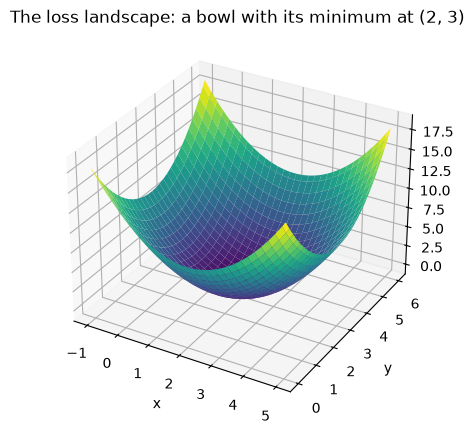

In [4]:
def bowl(x, y):
    return (x - 2) ** 2 + (y - 3) ** 2       # minimum at (2, 3)

# A grid of (x, y) points to evaluate the bowl on -- reused all section.
grid_x, grid_y = np.meshgrid(np.linspace(-1, 5, 60), np.linspace(0, 6, 60))

ax = plt.figure(figsize=(7, 5)).add_subplot(projection="3d")
ax.plot_surface(grid_x, grid_y, bowl(grid_x, grid_y), cmap="viridis")
ax.scatter([2], [3], [0], color="red", s=60)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("The loss landscape: a bowl with its minimum at (2, 3)")
plt.show()

Which hands us the entire strategy of machine learning in one line: *to
make a function smaller, be the ball — walk the other way from the
gradient.* Seen from above, with the arrows drawn:

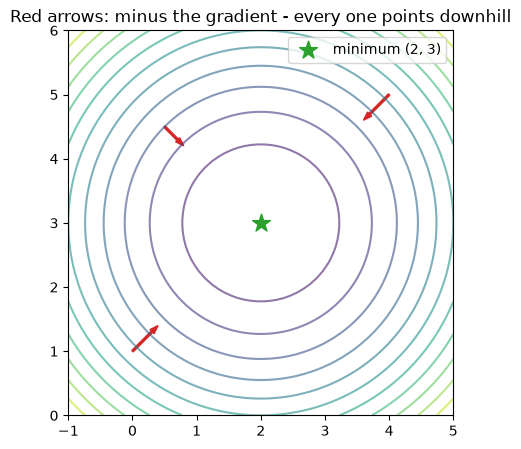

In [5]:
def grad_bowl(x, y, h=1e-6):
    """The two partial derivatives of the bowl, stacked: (df/dx, df/dy)."""
    df_dx = (bowl(x + h, y) - bowl(x, y)) / h
    df_dy = (bowl(x, y + h) - bowl(x, y)) / h
    return df_dx, df_dy

plt.figure(figsize=(6, 5))
plt.contour(grid_x, grid_y, bowl(grid_x, grid_y), levels=15, alpha=0.6)

for x0, y0 in [(0.0, 1.0), (4.0, 5.0), (0.5, 4.5)]:
    gx, gy = grad_bowl(x0, y0)
    plt.arrow(x0, y0, -0.1 * gx, -0.1 * gy,      # a short step downhill
              color="tab:red", width=0.03, length_includes_head=True)

plt.scatter([2], [3], marker="*", s=180, color="tab:green", zorder=5,
            label="minimum (2, 3)")
plt.legend(); plt.gca().set_aspect("equal")
plt.title("Red arrows: minus the gradient - every one points downhill")
plt.show()

Contour lines like a hiking map; the red arrows are **−∇f** at three
different spots. Every arrow points toward the bottom of the bowl. No
arrow needed a map of the whole landscape — each was computed *locally*,
from two wiggles.

## 7. Optimisation: gradient descent  *(slides 37, 39)*

The deck's framing *(slide 37)*: given a function f, **minimisation**
means finding the input where f is smallest. The f being minimised goes
by many names — objective, **loss**, cost — but in ML it is always some
measure of *how wrong the model currently is*.

The algorithm, in full:

1. start anywhere
2. compute the gradient
3. take a small step the *opposite* way: **x ← x − α ∇f**
4. repeat

α ("alpha", the **learning rate**) is the step size. Watch it run on the
bowl:

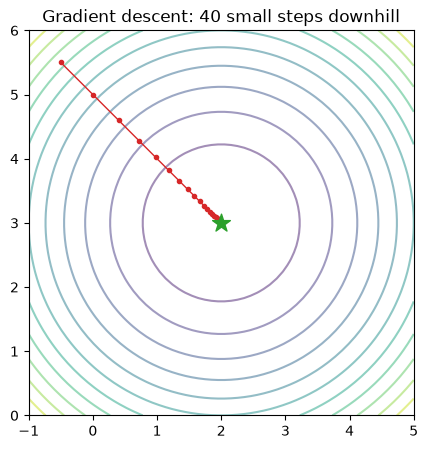

finished at: (2.000, 3.000)   (true minimum: (2, 3))


In [6]:
alpha = 0.1
x, y = -0.5, 5.5                       # start far from the minimum
path_x, path_y = [x], [y]

for step in range(40):
    gx, gy = grad_bowl(x, y)
    x = x - alpha * gx                 # step the OPPOSITE way
    y = y - alpha * gy
    path_x.append(x)
    path_y.append(y)

plt.figure(figsize=(6, 5))
plt.contour(grid_x, grid_y, bowl(grid_x, grid_y), levels=15, alpha=0.5)
plt.plot(path_x, path_y, "o-", color="tab:red", ms=3, lw=1)
plt.scatter([2], [3], marker="*", s=180, color="tab:green", zorder=5)
plt.gca().set_aspect("equal")
plt.title("Gradient descent: 40 small steps downhill")
plt.show()

print("finished at: ({:.3f}, {:.3f})   (true minimum: (2, 3))".format(x, y))

Big confident steps far from the bottom, tiny careful ones near it — not
because we programmed that, but because the gradient itself shrinks as
the ground flattens. The algorithm has a built-in brake: it behaves like
a ball rolling downhill through honey — always moving toward the valley,
never gathering enough speed to fly past it. (A real frictionless ball
*would* overshoot and oscillate; the plain algorithm carries no momentum,
though Module 8's fancier optimisers add some back on purpose, and call
it exactly that.)

> **Predict first.** One dial we chose freely: alpha = 0.1. What happens to the path if we set alpha = 1.1 — smooth, slower, or something worse?
>
> Put your answer in the chat before we run it.

In [ ]:
x, y = -0.5, 5.5
for step in range(8):
    gx, gy = grad_bowl(x, y)
    x = x - 1.1 * gx
    y = y - 1.1 * gy
    print("step", step, "-> ({:>7.1f}, {:>7.1f})   loss: {:.1f}".format(
        x, y, bowl(x, y)))

It **explodes** — each step overshoots the valley and lands higher up the
far wall, bouncing outward forever. Too small an α and training crawls;
too big and it diverges exactly like this. When a model's loss goes to
`nan` in Module 8, this cell is what happened, and "lower the learning
rate" is why that is the standard first aid.

(The deck's homework, slide 39, is an interactive tour of the cleverer
step-size strategies — benfrederickson.com/numerical-optimization — worth
twenty minutes before Wednesday.)

## 8. The payoff: learning a real line from real-shaped data

Assemble everything. The task that opens Module 4: given data points,
find the **best-fit line** y = mx + c. "Best" = the line minimising the
**mean squared error** — average of (prediction − truth)², our loss
function. Two knobs (m and c), one loss surface, and we now own a machine
for walking downhill on it.

Synthetic but realistic: resting heart rate against age.

In [ ]:
age = rng.uniform(20, 70, 60)
true_hr = 60 + 0.45 * age                       # nature's hidden line
resting_hr = true_hr + rng.normal(0, 4, 60)     # plus biology's noise

def loss(m, c):
    predictions = m * age + c
    return np.mean((predictions - resting_hr) ** 2)

print("loss of a terrible guess (m=0, c=60):", round(loss(0, 60), 1))

In [ ]:
m, c, alpha, h = 0.0, 60.0, 0.0002, 1e-6
history = []
for step in range(5000):
    grad_m = (loss(m + h, c) - loss(m, c)) / h       # two wiggles,
    grad_c = (loss(m, c + h) - loss(m, c)) / h       # one gradient
    m -= alpha * grad_m
    c -= alpha * grad_c
    history.append(loss(m, c))

print("learned: hr = {:.3f} * age + {:.1f}".format(m, c))
print("nature : hr = 0.450 * age + 60.0  (plus noise)")

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(age, resting_hr, s=18, alpha=0.7)
line_x = np.array([20, 70])                     # two points fix a line
plt.plot(line_x, m * line_x + c, color="tab:red", lw=2)
plt.xlabel("age"); plt.ylabel("resting heart rate")
plt.grid(alpha=0.3)
plt.title("The line the machine learned")
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.xlabel("step"); plt.ylabel("mean squared error")
plt.grid(alpha=0.3)
plt.title("Loss walking downhill")
plt.show()

Read the right-hand plot again: **that downhill curve is what "the model
is training" means**, in every ML system you will ever run. Module 4's
`LinearRegression().fit()` gets these same numbers by the linear-algebra
shortcut from last session (one `solve`); neural networks have no
shortcut, so they do exactly what this cell did — millions of knobs,
same walk.

You have now seen the whole secret:

- **loss** — a number measuring wrongness *(calculus needs a function)*
- **gradient** — which way is uphill *(partial derivatives, stacked)*
- **descent** — step the other way, repeat *(the learning rate matters)*

---

## Your turn

In [ ]:
# 1. Using derivative(), find the slope of f(x) = x**3 - 5*x at x = 2.
#    (Textbook check: 3x^2 - 5 at 2 gives 7.)

In [ ]:
# 2. Find where that same function's slope is zero near x = 1.3:
#    try x values 1.28, 1.29, ..., 1.31 in a loop and watch the sign flip.
#    Zero slope = flat ground = a minimum or maximum. Which is this one?
#    (Plot it if unsure.)

In [ ]:
# 3. Total dose: a drug infusion runs at rate r(t) = 5 * exp(-t / 2)
#    mg per hour. Use np.trapezoid on t = 0..12 hours to get total mg
#    delivered. Save it as `total_mg`.

In [ ]:
# 4. Re-run the section 8 fit with alpha = 0.002 (ten times larger).
#    Does it converge faster, or blow up? One-line comment on what you
#    saw, and why the bowl in section 7 already predicted it.

### Check your own work

In [ ]:
if "total_mg" not in dir():
    print("Finish task 3 first, then run this cell again.")
else:
    assert 9.5 < total_mg < 10.0, \
        "expected ~9.75 mg (the exact integral is 10 * (1 - e^-6)), got {:.2f}".format(total_mg)
    print("all checks pass: total dose = {:.2f} mg".format(total_mg))

### Stretch

1. Gradient descent on f(x) = x⁴ − 3x² + x, starting from x = 2 and then
   from x = −2. Different answers! This surface has **two valleys** — you
   have discovered local minima, the standard hazard of deep learning.
2. Time `np.polyfit(age, resting_hr, 1)` against the 5000-step loop.
   Same line, how much faster? That gap is the linear-algebra shortcut.
3. From the homework link (slide 39): read the Nelder-Mead section and
   write two sentences on how it differs from gradient descent.

### If you want the pictures again, slower

Three sources whose geometric style tonight borrowed, all free:

- **Dr Trefor Bazett** — [youtube.com/@DrTrefor](https://www.youtube.com/@DrTrefor):
  his calculus playlists (Calculus I and Multivariable Calculus) animate
  every idea from tonight — secants tilting into tangents, gradients on
  surfaces, the fundamental theorem — with the proofs there when you
  want them.
- **3Blue1Brown, *Essence of Calculus*** —
  [3blue1brown.com/topics/calculus](https://www.3blue1brown.com/topics/calculus):
  chapters 2 (the derivative paradox), 8 (integration and the
  fundamental theorem) and the gradient-descent chapters of his neural
  network series are tonight's sections 2, 4 and 7.
- **Khan Academy** —
  [khanacademy.org/math/differential-calculus](https://www.khanacademy.org/math/differential-calculus):
  worked exercises with instant feedback, good for drilling before the
  optimisation homework.

---

*Data Science & AI — Session 7. Covers Module 1 Part 2 slides 27–39.
Homework: the interactive optimisation tutorial linked on slide 39.*